In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
si = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_tumour_specific_Manuscript_v2.csv',index_col=0)

si_country =  pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata/MutWP1_CRC_core_data_Manuscript_v2.csv',index_col=0)

si_marcos = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V2_data/metadata_OG/CRC_metadata_2023SEP14.csv',index_col = 0)



In [3]:
# actually should just be able to use the activities from the MSI to figure out which ones are MSI

msi_matrix = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/MSA_testing_SBS96B/mutographs_SBS288_extraction_MSI/Samples.txt',
             index_col=0)

# mss_matrix =  pd.read_table('/Users/kazachkova/Documents/tscc/mutographs_SBS288_extraction/Samples.txt',
#              index_col=0)

mss_matrix =  pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/V3_data/SBS_MSS_matrices/CRC_Manuscript_Subset_v2.SBS288.all',
             index_col=0)

# and need to know which ones are SBS288D positive 

acts_MSA = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/pruned_attribution_CRC_Manuscript_denovo_SBS288_abs_mutations.csv',index_col=0)

In [5]:
pold1_samples = ['PD47115a','PD54896a','PD55467a']


In [6]:
sbs_all = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/MSA_testing_SBS96B/CRC_Manuscript_v1.SBS288.all',
             index_col=0)

# and we also need the indels 
import pandas as pd
indels_all = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/MSA_testing_SBS96B/CRC_Manuscript_v1.ID83.all',
             index_col=0)



indels_mss = indels_all.loc[:,mss_matrix.columns]
indels_msi = indels_all.loc[:,msi_matrix.columns]



summary_stats = pd.DataFrame(index = sbs_all.columns,
                            columns = ['total_SBS','total_IDs','status'])


summary_stats.loc[:,'total_SBS' ] = sbs_all.sum()
summary_stats.loc[:,'total_IDs' ] = indels_all.sum()

summary_stats.loc[msi_matrix.columns,'status'] = 'MSI'
summary_stats.loc[pold1_samples,'status'] = 'POLD1'

summary_stats.loc[acts_MSA[acts_MSA.loc[:,'SBS288D']>0].index,'status'] = 'MSS_SBS288D+'

summary_stats.loc[acts_MSA[acts_MSA.loc[:,'SBS288D']==0].index,'status'] = 'MSS_SBS288D-'


/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/2327091500.py:20: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  summary_stats.loc[:,'total_SBS' ] = sbs_all.sum()
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/2327091500.py:21: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  summary_stats.loc[:,'total_IDs' ] = indels_all.sum()


In [7]:
summary_stats_ = summary_stats.copy()
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('_','\n')
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('SBS288D','SBS_D')

summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('MSS\nSBS_D\+','MSS\nSBS_D+\n(n=428)')
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('POLD1','POLD1\n(n=3)')
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('MSI','MSI\n(n=153)')



/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/1758858676.py:5: FutureWarning: The default value of regex will change from True to False in a future version.
  summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('MSS\nSBS_D\+','MSS\nSBS_D+\n(n=428)')


In [9]:
si_marcos_full = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/V3_data/Metadata_TMB_Signatures_SBS_ID_DBS_CN_SV_Drivers_2024AUG21.tsv',
             index_col=0)


summary_stats['PGA'] = si_marcos_full.loc[:,'PGA']

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/2885917441.py:10: FutureWarning: The default value of regex will change from True to False in a future version.
  summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('MSS\nSBS_D\+','MSS\nSBS_D+\n(n=428)')
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/2885917441.py:11: FutureWarning: The default value of regex will change from True to False in a future version.
  summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('MSS\nSBS_D\-','MSS\nSBS_D-\n(n=374)')


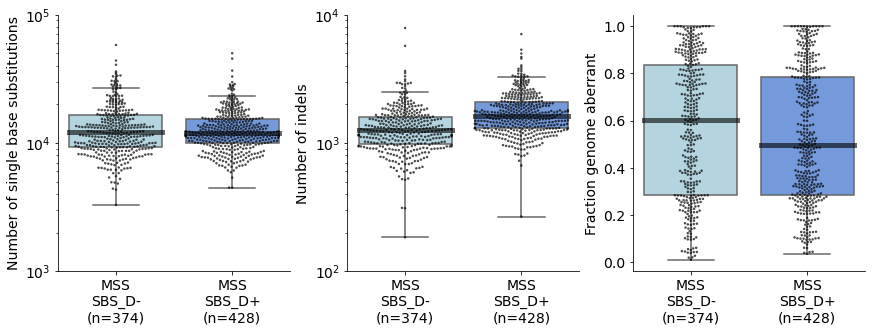

In [10]:
######### Figure 5a ##########

fig,ax = plt.subplots(1,3,figsize=(12,4.5),constrained_layout=True)

summary_stats_ = summary_stats.copy()
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('_','\n')
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('SBS288D','SBS_D')


summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('MSS\nSBS_D\+','MSS\nSBS_D+\n(n=428)')
summary_stats_.loc[:,'status'] = summary_stats_.loc[:,'status'].str.replace('MSS\nSBS_D\-','MSS\nSBS_D-\n(n=374)')


sns.boxplot(data = summary_stats_,
            x='status',
            y='total_SBS',
           order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
           palette=['lightblue','cornflowerblue'],
           medianprops=dict(color="black", alpha=0.6,
                                          linewidth=5),ax=ax[0],
           showfliers=False)


sns.swarmplot(data = summary_stats_,
            x='status',
            y='total_SBS',
          order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
          palette=['black','black'],ax=ax[0],alpha=.7,size=2.5)
           #color='black',alpha=.2)

ax[0].set_yscale('log')
# ax[0].locator_params(axis='y', nbins=4) 
# ax[0].locator_params(tight=True, nbins=4)
ax[0].set_yticks([1000, 10000,100000])
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of single base substitutions')


################################################

sns.boxplot(data = summary_stats_,
            x='status',
            y='total_IDs',
            order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
           palette=['lightblue','cornflowerblue'],
           medianprops=dict(color="black", alpha=0.6,
                                          linewidth=5),ax=ax[1],
           showfliers=False)


sns.swarmplot(data = summary_stats_,
            x='status',
            y='total_IDs',
          order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
           palette=['black','black'],ax=ax[1],alpha=.7,size=2.5)
           #color='black',alpha=.2)

ax[1].set_yscale('log')
ax[1].set_xlabel('')
ax[1].set_yticks([100, 1000,10000])

ax[1].set_ylabel('Number of indels')


################################################

sns.boxplot(data = summary_stats_,
            x='status',
            y='PGA',
         order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
           palette=['lightblue','cornflowerblue'],
           medianprops=dict(color="black", alpha=0.6,
                                          linewidth=5),ax=ax[2],
           showfliers=False)


sns.swarmplot(data = summary_stats_,
            x='status',
            y='PGA',
          order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
           palette=['black','black'],ax=ax[2],alpha=.7,size=2.5)
           #color='black',alpha=.2)

ax[2].set_xlabel('')
ax[2].set_ylabel('Fraction genome aberrant')



for i in range(0,3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

    for item in ([ ax[i].title,  ax[i].xaxis.label,  ax[i].yaxis.label] +
                  ax[i].get_xticklabels() +  ax[i].get_yticklabels()):
        item.set_fontsize(14)
        
# plt.savefig('plots_for_paper/comparing_post_neg.png',dpi=300)


In [11]:
# we need to derive the q-values from logistc regression models 

purity = pd.Series(index = summary_stats.index)
# now do it for all our samples of interest
import os

for sample in purity.index:
    
    if not os.path.exists('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/rho_and_psi/' + sample + '.battenberg.rho_and_psi.txt'):
                          continue
  
    
    rho_psi = pd.read_table('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/rho_and_psi/' + sample + '.battenberg.rho_and_psi.txt')

    purity.loc[sample] = rho_psi[rho_psi.loc[:,'is.best'] == True].loc[:,'rho'].values[0]
    
    

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/1998333673.py:3: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  purity = pd.Series(index = summary_stats.index)


In [14]:
summary_stats['country'] = si_country.loc[:,'country']
summary_stats['tumorsite_group'] = si_marcos.loc[:,'tumorsite_group']
summary_stats['sex'] = si_marcos.loc[:,'sex']
summary_stats['age_diag'] = si_country.loc[:,'age_diag']
summary_stats['purity'] = purity

In [15]:
summary_stats.loc[:,'status'] = summary_stats.loc[:,'status'].fillna('')

In [17]:
# for SBS mutations 


MSS_only = summary_stats[summary_stats.loc[:,'status'].str.contains('MSS')]

MSS_only.loc[:,'status'] = MSS_only.loc[:,'status'].str.replace('_','\n')

MSS_only['SBS288D_bool'] = (MSS_only.loc[:,'status'] == 'MSS\nSBS288D+').astype(int)


import statsmodels.api as sm

import statsmodels.formula.api as smf

model = smf.glm(formula = 'SBS288D_bool' + " ~ total_SBS + age_diag + country + tumorsite_group + purity + sex", 
                data =MSS_only, family = sm.families.Binomial())
                #family = sm.families.Binomial())

    
result = model.fit()
result_table = result.summary2().tables[1]
result_table.loc['total_SBS']

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/1313506063.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MSS_only.loc[:,'status'] = MSS_only.loc[:,'status'].str.replace('_','\n')
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/1313506063.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MSS_only['SBS288D_bool'] = (MSS_only.loc[:,'status'] == 'MSS\nSBS288D+').astype(int)


Coef.      -0.000026
Std.Err.    0.000012
z          -2.077350
P>|z|       0.037769
[0.025     -0.000050
0.975]     -0.000001
Name: total_SBS, dtype: float64

In [18]:
# for ID mutations 

model = smf.glm(formula = 'SBS288D_bool' + " ~ total_IDs + age_diag + country + tumorsite_group + purity + sex", 
                data =MSS_only, family = sm.families.Binomial())
                #family = sm.families.Binomial())

    
result = model.fit()
result_table = result.summary2().tables[1]
result_table.loc['total_IDs']

Coef.       1.084312e-03
Std.Err.    1.515322e-04
z           7.155653e+00
P>|z|       8.327532e-13
[0.025      7.873142e-04
0.975]      1.381309e-03
Name: total_IDs, dtype: float64

In [19]:
# for PGA

model = smf.glm(formula = 'SBS288D_bool' + " ~ PGA + age_diag + country + tumorsite_group + purity + sex", 
                data =MSS_only.dropna(), family = sm.families.Binomial())
                #family = sm.families.Binomial())

    
result = model.fit()
result_table = result.summary2().tables[1]
result_table.loc['PGA']


Coef.      -0.527518
Std.Err.    0.271350
z          -1.944052
P>|z|       0.051889
[0.025     -1.059354
0.975]      0.004318
Name: PGA, dtype: float64

In [20]:
# collect and correct the p-values

from statsmodels.stats.multitest import multipletests


multipletests([0.037769,8.327532e-13,0.051889],method='fdr_bh')[1]

array([5.1889000e-02, 2.4982596e-12, 5.1889000e-02])

In [21]:
######### Figure 5b ##########

# need to do the comparison between SBS_D activity and all of the indel signatures 

indel_acts = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/checking_SBS288D_other_tissues/other_mutation_types_CRC/ID83/output_tables/pruned_attribution_CRC_Manuscript_COSMIC_ID83_abs_mutations.csv',
                      index_col=0)

acts_denovo_without_us = pd.read_csv('/Users/kazachkova/Documents/tscc/projects/mutographs/CRC/V3_data/pruned_attribution_CRC_Manuscript_denovo_SBS288_abs_mutations.csv',index_col=0)


In [22]:
from scipy import stats 

corrs_with_id1 = pd.Series(index = list(acts_denovo_without_us.loc[:,'SBS288A':'SBS288P'].columns))

i=0
j=0
for sig in list(acts_denovo_without_us.loc[:,'SBS288A':'SBS288P'].columns):
#     sns.scatterplot(acts_denovo_without_us.loc[:,sig],
#            indel_acts.loc[:,'total_indels'],ax=ax[i,j],color='lightblue',
#                    edgecolor='black')#scatter_kws={'alpha':.5,
# #                                                                    "edgecolor":'black','color':'lightblue'})
    
    
    correlation = stats.spearmanr(acts_denovo_without_us.loc[:,sig],
           indel_acts.loc[acts_denovo_without_us.index,'ID1'])[0]
    
    corrs_with_id1.loc[sig] = correlation

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/1771446010.py:3: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  corrs_with_id1 = pd.Series(index = list(acts_denovo_without_us.loc[:,'SBS288A':'SBS288P'].columns))


In [24]:
# need to find out which ones are sigificant

pvals = pd.Series(index = acts_denovo_without_us.loc[:,'SBS288A':'SBS288P'].columns)
corrs = pd.Series(index = acts_denovo_without_us.loc[:,'SBS288A':'SBS288P'].columns)

for sig in acts_denovo_without_us.loc[:,'SBS288A':'SBS288P'].columns:
    pvals.loc[sig] = stats.spearmanr(indel_acts.loc[:,'ID1'],acts_denovo_without_us.loc[:,sig])[1]
    corrs.loc[sig] = stats.spearmanr(indel_acts.loc[:,'ID1'],acts_denovo_without_us.loc[:,sig])[0]    

from statsmodels.stats.multitest import multipletests
qvals = pd.Series(multipletests(pvals.dropna(),method='fdr_bh')[1],index =pvals.dropna().index ) 


qvals_annot = qvals.copy().astype(str)

qvals_annot[qvals<.001] = '*'
# qvals_annot[qvals<.01] = '**'
# qvals_annot[qvals<.001] = '***'
# qvals_annot[qvals<.0001] = '****'


qvals_annot[qvals>.001] = ''

for_annot = pd.DataFrame(round(corrs,2).astype(str) +  qvals_annot)

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/3524372725.py:3: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  pvals = pd.Series(index = acts_denovo_without_us.loc[:,'SBS288A':'SBS288P'].columns)
/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_76117/3524372725.py:4: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  corrs = pd.Series(index = acts_denovo_without_us.loc[:,'SBS288A':'SBS288P'].columns)


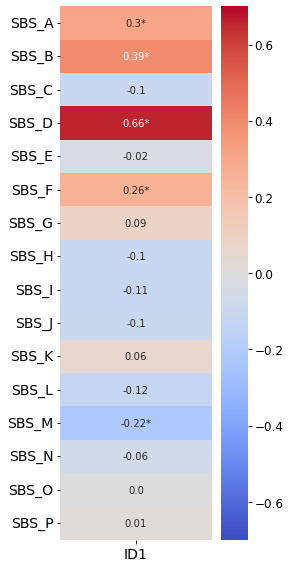

In [27]:
######### Figure 5b ##########


corrs_with_id1.name = 'ID1'

all_corrs = pd.concat([corrs_with_id1,
                      ],axis=1)

fig,ax = plt.subplots(figsize=(4,8))

all_corrs.index = all_corrs.index.str.replace('_',' ')

all_corrs.index = all_corrs.index.str.replace('288','_')
all_corrs.index = all_corrs.index.str.replace('diag','diagnosis')


sns.heatmap(all_corrs,cmap='coolwarm',vmin=-.7,vmax=.7,annot=for_annot,
           fmt='')


for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(14)
    
cbar = ax.collections[0].colorbar
# here set the labelsize by 20
cbar.ax.tick_params(labelsize=12)
    
plt.tight_layout()

# plt.savefig('plots_for_paper/indel_correlations_DE_NOVO.png',dpi=300,bbox_inches='tight',
#            facecolor='white')

In [28]:
# okay now we move on to the last panel 

In [ ]:
######### Figure 5c ##########

# need to do the topography plots

(0.75, 1.05)

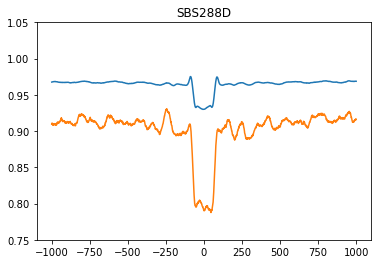

In [30]:
# topography data for SBS_D 



import os

files = os.listdir('/Users/kazachkova/Documents/tscc/restricted/topography_figures_MSS/nucleosome_occupancy_data/signaturebased/')


files = pd.Series(files)

files2 = files[files.str.contains('SBS288B')]
files3 = files2[files2.str.contains('AverageSignalArray.txt')]
files4 = files3[files3.str.contains('sim')]
files4


average_signal_array_SBS288D = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/topography_figures_MSS/nucleosome_occupancy_data/signaturebased/SBS288D_AverageSignalArray.txt',
             header=None).T



files2 = files[files.str.contains('SBS288D')]
files3 = files2[files2.str.contains('AverageSignalArray.txt')]
files4 = files3[files3.str.contains('sim')]


files4

df_288d = pd.DataFrame(index=list(range(1,101)),
                       columns=list(range(0,2001)),dtype=float)
i=1
for file in files4:
   
    sim = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/topography_figures_MSS/nucleosome_occupancy_data/signaturebased/' + file,
                 header=None).T
    df_288d.loc[i] = sim.loc[:,0]
    i+=1

    

df_288d_mean_sim = df_288d.mean()

df_288d_mean_sim.index = df_288d_mean_sim.index - 1000

average_signal_array_SBS288D.index = average_signal_array_SBS288D.index - 1000

fig,ax = plt.subplots(figsize=(6,4))
plt.plot(df_288d_mean_sim)
plt.plot(average_signal_array_SBS288D.loc[:,0])
plt.title('SBS288D')
plt.ylim(.75,1.05)

In [31]:
# need to also make a plot for the POLD1 samples

# same thing 10c
average_signal_array_SBS10c = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/topography_figures_POLD1/nucleosome_occupancy_data/signaturebased/SBS10c_AverageSignalArray.txt',
             header=None).T



files2 = files[files.str.contains('SBS10c')]
files3 = files2[files2.str.contains('AverageSignalArray.txt')]
files4 = files3[files3.str.contains('sim')]


files4

df_10c = pd.DataFrame(index=list(range(1,101)),
                       columns=list(range(0,2001)),dtype=float)
i=1
for file in files4:
   
    sim = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/topography_figures_POLD1/nucleosome_occupancy_data/signaturebased/' + file,
                 header=None).T
    df_10c.loc[i] = sim.loc[:,0]
    i+=1

    

df_10c_mean_sim = df_10c.mean()

df_10c_mean_sim.index = df_10c_mean_sim.index - 1000

average_signal_array_SBS10c.index = average_signal_array_SBS10c.index - 1000

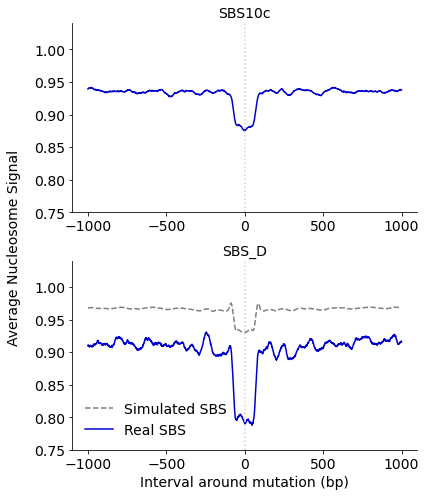

In [32]:
fig,ax = plt.subplots(2,1,figsize=(6,7),sharey=True)


ax[0].plot(df_10c_mean_sim,color='grey',linestyle='--')
ax[0].plot(average_signal_array_SBS10c.loc[:,0],color='mediumblue')
ax[0].axvline(0,color='lightgrey',linestyle=':')
ax[0].set_title('SBS10c')
ax[0].set_ylim(.75,1.04)


ax[1].plot(df_288d_mean_sim,color='grey',linestyle='--',label='Simulated SBS')
ax[1].plot(average_signal_array_SBS288D.loc[:,0],color='mediumblue',label='Real SBS')
ax[1].axvline(0,color='lightgrey',linestyle=':')
ax[1].set_title('SBS_D')
ax[1].legend(frameon=False,fontsize=14)
ax[1].set_ylim(.75,1.04)

# ax[0].set_ylabel('Average Nucleosome Signal')

fig.supylabel('Average Nucleosome Signal', fontsize=14)


for i in range(0,2):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    
    for item in ([ax[i].title, ax[i].xaxis.label, ax[i].yaxis.label] +
             ax[i].get_xticklabels() + ax[i].get_yticklabels()):
        item.set_fontsize(14)
        
ax[0].locator_params(axis='x', nbins=5)

ax[1].locator_params(axis='x', nbins=5)       
plt.xlabel('Interval around mutation (bp)', fontsize=14)

plt.tight_layout()

# plt.savefig('plots_for_paper/topography_replot_sbs10c_v2.png',dpi=300)